In [12]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import tifffile as tiff
import sys
sys.path.append("..")
sys.path.append("../models")

from models.semisupervised_Unet_ViT import U_net_ViT


Using MPS


In [13]:
#Run inference on validation set + save results
import torchvision.transforms.functional as TF


In [14]:
# Define your model architecture
 # A small configuration to avoid MPS OOM — lower channels / tokens
encode_in = (1, 64)      # two encode layers example; adapt to your prior network shape
encode_out = (64, 128)
decode_in = (256, 128)
decode_out = (128, 64)

student = U_net_ViT(encode_in=encode_in, encode_out=encode_out, decode_in=decode_in, decode_out=decode_out,
                       vit_num_layers=1, vit_num_heads=2, vit_mlp_dim=None, vit_dropout=0.0,)
device = torch.device("mps")

# Load saved weights
state_dict = torch.load("../unet_vit_semisup_student.pth", map_location=device)

# strict=False ignores keys in state_dict that do not match the model
student.load_state_dict(state_dict, strict=False)

student.to(device)
student.eval()

U_net_ViT(
  (encode): ModuleList(
    (0): EncodeBlock(
      (conv_block): Convblock(
        (p1): PrintSize()
        (p2): PrintSize()
        (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU(inplace=True)
        (dropout): Dropout2d(p=0.0, inplace=False)
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): EncodeBlock(
      (conv_block): Convblock(
        (p1): PrintSize()
        (p2): PrintSize()
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 128

In [15]:
class MicroCTDataset(Dataset):
    """
    Loads TIFF images and masks using tifffile so 16-bit intensities
    are NOT destroyed (PIL breaks 16-bit TIFFs).
    """

    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.img_files = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(".tif")
        ])

        self.mask_files = [
            f.replace(".tif", "").replace("image_v2_", "image_v2_mask_") + ".tif"
            for f in self.img_files
        ]

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        # --- LOAD TIFF PROPERLY (16-bit OK) ---
        img = tiff.imread(img_path)
        mask = tiff.imread(mask_path)

        # If 3D → pick center slice (same as your testing code)
        if img.ndim == 3:
            img = img[img.shape[0] // 2]
        if mask.ndim == 3:
            mask = mask[mask.shape[0] // 2]

        # --- Convert to float32 in [0,1] ---
        img = img.astype("float32")
        img = img / img.max()   # normalize safely

        mask = mask.astype("float32")
        mask = (mask > 0).astype("float32")  # binary mask

        # --- Convert to tensors ---
        img = torch.from_numpy(img).unsqueeze(0)  # shape: [1,H,W]
        mask = torch.from_numpy(mask).unsqueeze(0)

        # --- Apply augmentations ---
        if self.transform:
            data = torch.cat([img, mask], dim=0)  # [2,H,W]
            data = self.transform(data)
            img, mask = data[0].unsqueeze(0), data[1].unsqueeze(0)

        return img, mask


In [16]:
img_dir = "../datas/Original Images"
mask_dir = "../datas/Original Masks"

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(10),
    # T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.0)),
])

dataset = MicroCTDataset(img_dir, mask_dir, transform=train_transform)

# 80/20 split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))


Train samples: 17
Val samples: 5


In [17]:
save_dir = "../datas/predictions/"
os.makedirs(save_dir, exist_ok=True)

with torch.no_grad():
    for i, (img, _) in enumerate(val_loader):
        img = img.to(device)
        logits = student(img)
        prob = torch.sigmoid(logits).cpu()  # convert to probabilities
        pred_mask = (prob > 0.5).float()    # threshold

        # Save each prediction as image
        out = TF.to_pil_image(pred_mask.squeeze(0))
        out.save(f"{save_dir}/pred_{i:03d}.tif")

print("Predictions saved ✔")


Predictions saved ✔


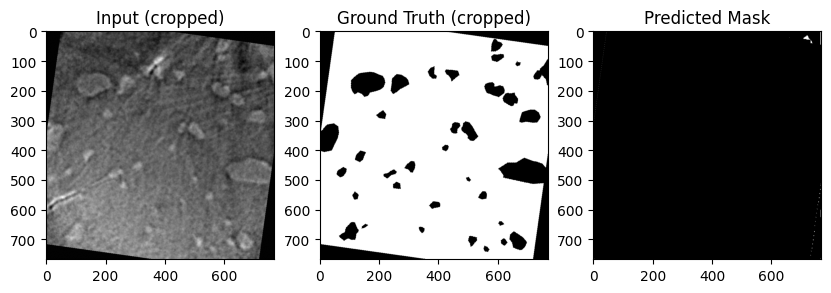

In [18]:
# Pick a sample from dataset
sample_img, sample_mask = dataset[0]

with torch.no_grad():
    logits = student(sample_img.unsqueeze(0).to(device))  # add batch dim
    prob = torch.sigmoid(logits).cpu()

    # Crop to match original mask size if needed
    _, _, ph, pw = prob.shape
    sample_img_cropped = sample_img[:, :ph, :pw]
    sample_mask_cropped = sample_mask[:, :ph, :pw]
    pred_mask = (prob > 0.5).float().squeeze(0).squeeze(0)

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(sample_img_cropped.squeeze(), cmap="gray")
plt.title("Input (cropped)")

plt.subplot(1,3,2)
plt.imshow(sample_mask_cropped.squeeze(), cmap="gray")
plt.title("Ground Truth (cropped)")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")

plt.show()
